In [1]:
# 0. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# 1. 원본 데이터 로드
# RFM은 거래 기반 → 인코딩 전 원본 데이터 사용
df = pd.read_excel('../data/Ecommerce_Dataset.xlsx', sheet_name='E Comm')
df = df.drop_duplicates()
df = df.dropna(subset=['Tenure', 'Churn'])

print(f'데이터 크기: {df.shape[0]:,}행')
df[['Tenure', 'DaySinceLastOrder', 'OrderCount', 'CashbackAmount', 'Churn']].head()

데이터 크기: 5,366행


,Tenure,DaySinceLastOrder,OrderCount,CashbackAmount,Churn
0,4.0,5.0,1.0,159.93,1
3,0.0,3.0,1.0,134.07,1
4,0.0,3.0,1.0,129.60,1
5,0.0,7.0,6.0,139.19,1
8,13.0,2.0,1.0,126.83,1


In [5]:
# 2. RFM 점수 계산
rfm = df[['DaySinceLastOrder', 'OrderCount', 'CashbackAmount', 'Churn']].copy()

# NaN 제거
rfm = rfm.dropna()

# 4분위로 점수 부여 (1~4점)
rfm['R_Score'] = pd.qcut(rfm['DaySinceLastOrder'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['OrderCount'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['CashbackAmount'], q=4, labels=[1, 2, 3, 4]).astype(int)

# RFM 총점
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(f'RFM 계산 완료: {rfm.shape[0]:,}명')
rfm.head(10)

RFM 계산 완료: 4,801명


,DaySinceLastOrder,OrderCount,CashbackAmount,Churn,R_Score,F_Score,M_Score,RFM_Score
0,5.0,1.0,159.93,1,2,1,2,5
3,3.0,1.0,134.07,1,3,1,1,5
4,3.0,1.0,129.60,1,3,1,1,5
5,7.0,6.0,139.19,1,2,4,1,7
8,2.0,1.0,126.83,1,4,1,1,6
10,8.0,15.0,295.45,1,1,4,4,9
11,0.0,1.0,153.81,1,4,1,2,7
12,2.0,2.0,134.41,1,4,2,1,7
13,0.0,1.0,133.88,1,4,1,1,6
14,7.0,4.0,196.19,1,2,4,4,10


In [6]:
# 3. 고객 세그먼트 분류
# 논문 기준: Best, Loyal, Big Spender, Promising, New, Lost Potential, Lost

def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    total = r + f + m

    if total >= 10:
        return 'Best'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif m >= 4:
        return 'Big Spender'
    elif r >= 3 and total >= 7:
        return 'Promising'
    elif r >= 3:
        return 'New'
    elif r <= 2 and total >= 6:
        return 'Lost Potential'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print('=== 세그먼트별 고객 수 ===')
print(rfm['Segment'].value_counts())

=== 세그먼트별 고객 수 ===
Segment
Lost Potential    1174
Promising          836
Big Spender        796
Loyal              578
Best               547
New                517
Lost               353
Name: count, dtype: int64


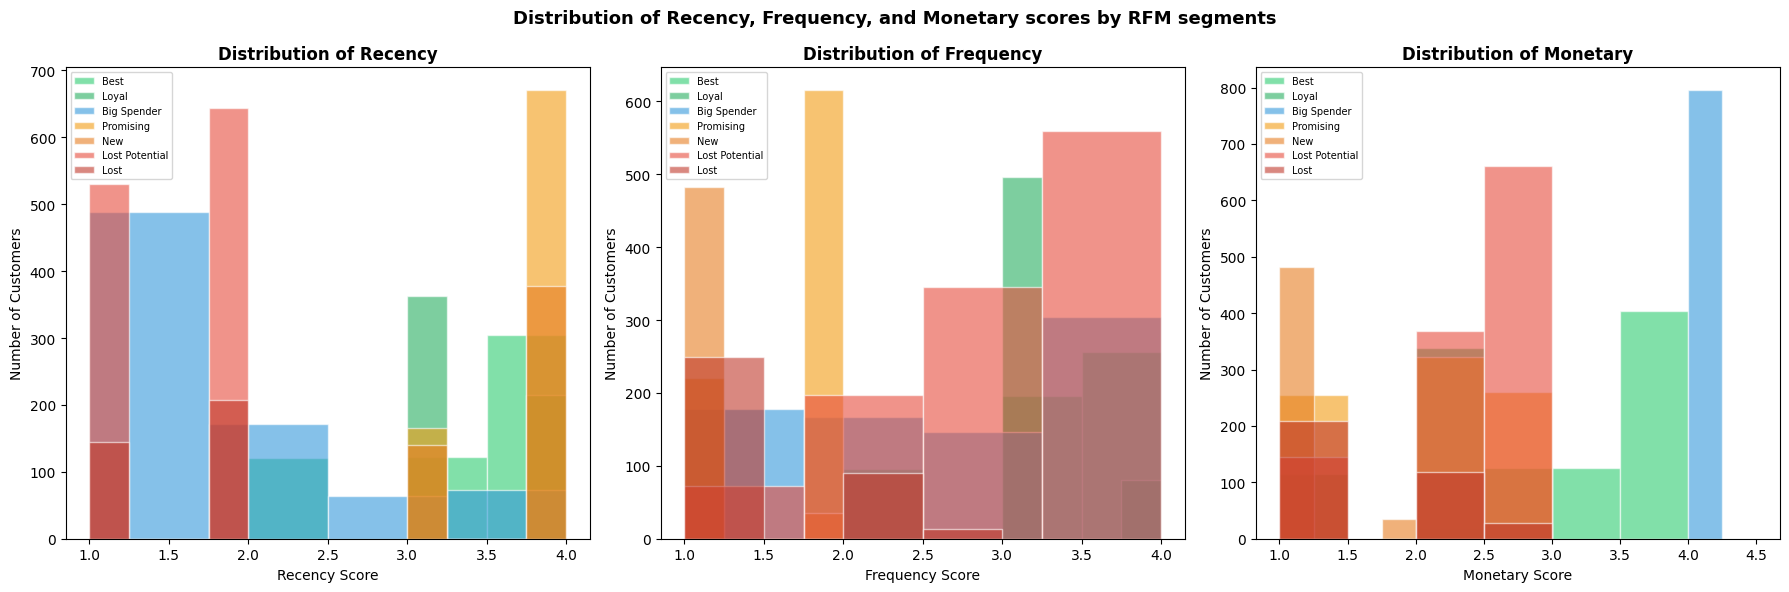

In [ ]:
# 4. RFM 세그먼트별 분포 시각화 (논문 Fig 2 재현)
segment_order = ['Best', 'Loyal', 'Big Spender', 'Promising', 'New', 'Lost Potential', 'Lost']
colors = ['#2ecc71', '#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('R_Score', 'Distribution of Recency', 'Recency Score'),
    ('F_Score', 'Distribution of Frequency', 'Frequency Score'),
    ('M_Score', 'Distribution of Monetary', 'Monetary Score')
]

for ax, (metric, title, xlabel) in zip(axes, metrics):
    for seg, color in zip(segment_order, colors):
        seg_data = rfm[rfm['Segment'] == seg][metric]
        if len(seg_data) > 0:
            ax.hist(seg_data, alpha=0.6, label=seg, color=color, bins=4, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of Customers')
    ax.legend(fontsize=7)

plt.suptitle('Distribution of Recency, Frequency, and Monetary scores by RFM segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/06_rfm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

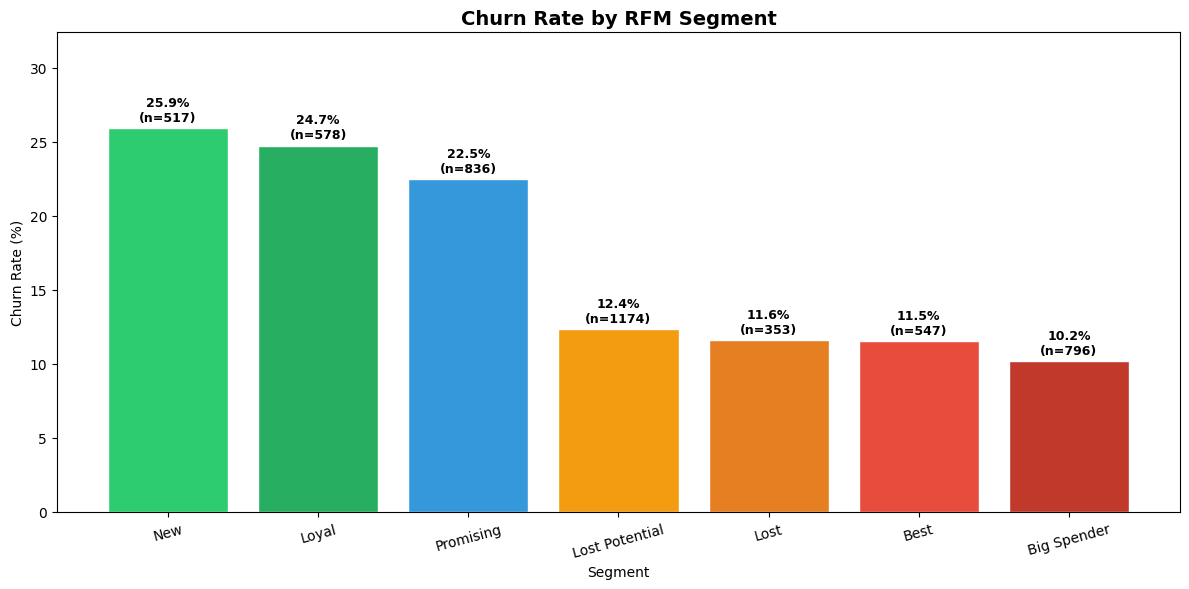

In [8]:
# 5. 세그먼트별 이탈률
churn_by_segment = rfm.groupby('Segment')['Churn'].agg(['mean', 'count']).reset_index()
churn_by_segment.columns = ['Segment', 'Churn_Rate', 'Count']
churn_by_segment['Churn_Rate'] = churn_by_segment['Churn_Rate'] * 100
churn_by_segment = churn_by_segment.sort_values('Churn_Rate', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(churn_by_segment['Segment'], churn_by_segment['Churn_Rate'], color=colors[:len(churn_by_segment)], edgecolor='white')
for bar, (_, row) in zip(bars, churn_by_segment.iterrows()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{row["Churn_Rate"]:.1f}%\n(n={row["Count"]})', ha='center', fontsize=9, fontweight='bold')

plt.title('Churn Rate by RFM Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, churn_by_segment['Churn_Rate'].max() * 1.25)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/figures/06_churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

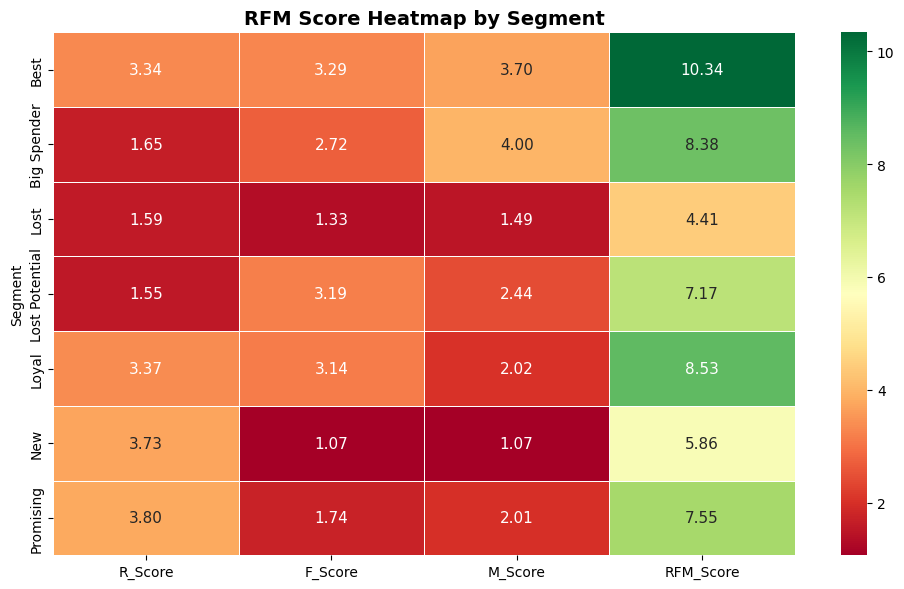

In [9]:
# 6. 세그먼트별 RFM 평균값 히트맵
rfm_mean = rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].mean()
rfm_mean = rfm_mean.loc[rfm_mean.index.intersection(segment_order)]

plt.figure(figsize=(10, 6))
sns.heatmap(rfm_mean, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('RFM Score Heatmap by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/06_rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 7. 세그먼트별 리텐션 전략 출력 (논문 Table 재현)
strategies = {
    'Best':           '💎 VIP 멤버십, 얼리 액세스, 레퍼럴 프로그램',
    'Loyal':          '🏆 로열티 리워드, 감사 쿠폰, 프리미엄 혜택',
    'Big Spender':    '💰 고가 상품 추천, 프리미엄 서비스 제안',
    'Promising':      '🌱 크로스셀링, 제품 교육, 첫 구매 인센티브',
    'New':            '👋 온보딩 캠페인, 웰컴 쿠폰, 재구매 유도',
    'Lost Potential': '⚠️  맞춤 할인, 타겟 커뮤니케이션, 재활성화',
    'Lost':           '🚨 윈백 캠페인, 대폭 할인, 이탈 원인 파악'
}

print('=' * 65)
print('📋 Personalized Retention Strategy by RFM Segment')
print('=' * 65)
for seg in segment_order:
    count = rfm[rfm['Segment'] == seg].shape[0]
    churn = rfm[rfm['Segment'] == seg]['Churn'].mean() * 100
    print(f'\n[{seg}] ({count}명, 이탈률 {churn:.1f}%)')
    print(f'  전략: {strategies[seg]}')

print()
print('=' * 65)
print('🎉 전체 파이프라인 완료!')
print('   01_EDA → 02_preprocessing → 03_modeling')
print('   → 04_xai → 05_survival → 06_rfm')

📋 Personalized Retention Strategy by RFM Segment

[Best] (547명, 이탈률 11.5%)
  전략: 💎 VIP 멤버십, 얼리 액세스, 레퍼럴 프로그램

[Loyal] (578명, 이탈률 24.7%)
  전략: 🏆 로열티 리워드, 감사 쿠폰, 프리미엄 혜택

[Big Spender] (796명, 이탈률 10.2%)
  전략: 💰 고가 상품 추천, 프리미엄 서비스 제안

[Promising] (836명, 이탈률 22.5%)
  전략: 🌱 크로스셀링, 제품 교육, 첫 구매 인센티브

[New] (517명, 이탈률 25.9%)
  전략: 👋 온보딩 캠페인, 웰컴 쿠폰, 재구매 유도

[Lost Potential] (1174명, 이탈률 12.4%)
  전략: ⚠️  맞춤 할인, 타겟 커뮤니케이션, 재활성화

[Lost] (353명, 이탈률 11.6%)
  전략: 🚨 윈백 캠페인, 대폭 할인, 이탈 원인 파악

🎉 전체 파이프라인 완료!
   01_EDA → 02_preprocessing → 03_modeling
   → 04_xai → 05_survival → 06_rfm
